Import Libraries

In [3]:
import os
import re
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

In this section, the raw news text dataset is loaded, cleaned, visualized, tokenized, and padded. These steps are required before training RNN and LSTM models because neural networks cannot directly process raw text.

Load the Dataset

In [4]:
def find_news_csv():
    input_root = Path("/kaggle/input/datasets/aakritirimal/news-dataset")
    for csv_file in input_root.rglob("truevsfakenews.csv"):
        return csv_file
    raise FileNotFoundError("truevsfakenews.csv was not found. Please attach the dataset in Kaggle.")

csv_path = find_news_csv()
print("CSV path:", csv_path)

df = pd.read_csv(csv_path)
print("Dataset shape:", df.shape)
display(df.head())

CSV path: /kaggle/input/datasets/aakritirimal/news-dataset/10.True vs. Fake News Dataset/truevsfakenews.csv
Dataset shape: (20000, 2)


,text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,true
1,Women should get as far away from Oklahoma as ...,fake
2,Another huge crowd of Americans tuned in last ...,fake
3,Donald Trump is desperate to stop the investig...,fake
4,"(Reuters) - Planned Parenthood, the U.S. medic...",true


In [5]:
print("Columns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Columns:
Index(['text', 'label'], dtype='object')

Missing values:
text     0
label    0
dtype: int64

Class distribution:
label
true    10000
fake    10000
Name: count, dtype: int64


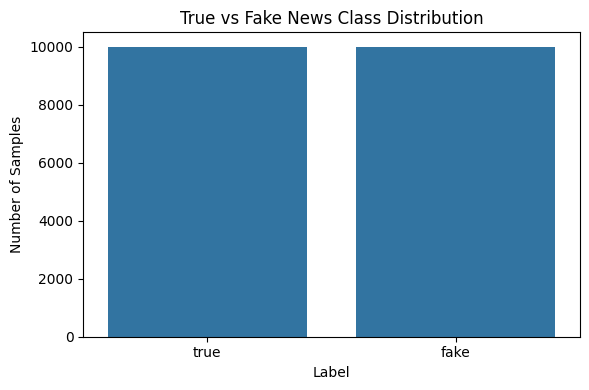

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.title("True vs Fake News Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

Dataset Description

The dataset contains news text labelled as either true or fake. It has 20,000 records with two columns: text and label. The dataset is balanced, with 10,000 true news samples and 10,000 fake news samples. There are no missing values, so no rows needed to be removed before preprocessing.

Clean the Text

In [8]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

contraction_map = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
    "i've": "i have",
    "you've": "you have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "they'll": "they will",
}

def expand_contractions(text):
    for short_form, full_form in contraction_map.items():
        text = text.replace(short_form, full_form)
    return text

def clean_news_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]
    return " ".join(words)

In [9]:
df["clean_text"] = df["text"].apply(clean_news_text)
display(df[["text", "clean_text", "label"]].head(3))

,text,clean_text,label
0,WASHINGTON (Reuters) - The Republican and Demo...,washington reuters republican democratic leade...,true
1,Women should get as far away from Oklahoma as ...,woman get far away oklahoma soon possible chri...,fake
2,Another huge crowd of Americans tuned in last ...,another huge crowd american tuned last week re...,fake


The text was cleaned by converting all words to lowercase, expanding contractions, removing URLs, mentions, hashtags, numbers, and special characters. Stopwords were removed because common words such as "the", "is", and "and" usually add little meaning for classification. Lemmatization was applied to reduce words to their base form, helping the model treat similar word forms consistently.

Visualize the Cleaned Data

In [11]:
all_clean_words = " ".join(df["clean_text"]).split()
word_frequency = Counter(all_clean_words)

common_words_df = pd.DataFrame(
    word_frequency.most_common(20),
    columns=["word", "frequency"]
)

display(common_words_df)

,word,frequency
0,trump,101138
1,said,61943
2,president,31940
3,republican,31476
4,would,30325
5,state,29487
6,people,21270
7,donald,20685
8,one,19238
9,house,19177


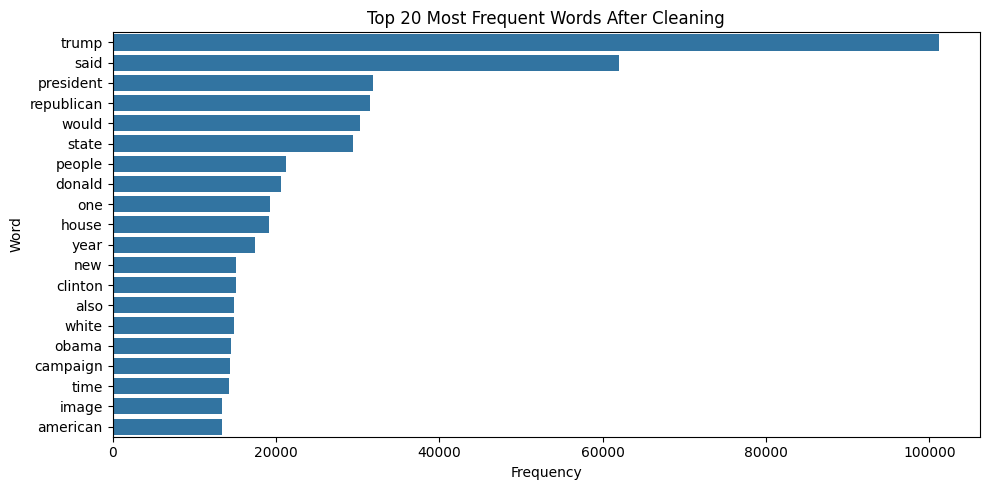

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=common_words_df, x="frequency", y="word")
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

The frequent-word visualization helps understand the most common terms after preprocessing. This is useful for checking whether the cleaning process worked properly and whether meaningful words remain in the dataset.

Encode Labels

In [13]:
label_map = {
    "fake": 0,
    "true": 1
}

df["label_encoded"] = df["label"].map(label_map)

display(df[["label", "label_encoded"]].head())
print(df["label_encoded"].value_counts())

,label,label_encoded
0,true,1
1,fake,0
2,fake,0
3,fake,0
4,true,1


label_encoded
1    10000
0    10000
Name: count, dtype: int64


Split the Dataset into Training and Testing Sets

In [14]:
X = df["clean_text"].values
y = df["label_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


Tokenization and Padding

In [15]:
VOCAB_SIZE = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

sequence_lengths = [len(seq) for seq in train_sequences]
MAX_LENGTH = int(np.percentile(sequence_lengths, 95))

print("Vocabulary size used:", VOCAB_SIZE)
print("95th percentile sequence length:", MAX_LENGTH)

X_train_padded = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_padded.shape)
print("Testing padded shape:", X_test_padded.shape)

Vocabulary size used: 20000
95th percentile sequence length: 492
Training padded shape: (16000, 492)
Testing padded shape: (4000, 492)


Keras Tokenizer was used to convert cleaned text into integer sequences. Each word is represented by a number based on the vocabulary learned from the training data. Padding was applied so all sequences have the same length. The maximum length was selected using the 95th percentile of training sequence lengths to avoid making all sequences unnecessarily long because of a few outliers.

4.5.2 Model Building and Training
Three models are built for text classification:

Simple RNN with trainable Embedding layer
LSTM with trainable Embedding layer
LSTM with pretrained Word2Vec embeddings

Define Callbacks and Plot Function

In [17]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

callbacks = [early_stop, reduce_lr]

def plot_training_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

Model 1: Simple RNN with Trainable Embedding Layer

In [18]:
EMBEDDING_DIM = 128

simple_rnn_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    layers.SimpleRNN(64),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

simple_rnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

simple_rnn_model.summary()

I0000 00:00:1778340249.293582      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778340249.299628      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 492, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

The first model uses a trainable Embedding layer followed by a SimpleRNN layer. The embedding layer learns word representations during training. The SimpleRNN processes the text sequence step by step. A sigmoid output layer is used because the task is binary classification: fake or true.

In [20]:
start_time = time.time()

simple_rnn_history = simple_rnn_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

simple_rnn_time = time.time() - start_time
print("Simple RNN training time:", simple_rnn_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.6368 - loss: 0.6376 - val_accuracy: 0.5956 - val_loss: 0.6629 - learning_rate: 5.0000e-04
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6009 - loss: 0.6476 - val_accuracy: 0.5997 - val_loss: 0.6568 - learning_rate: 5.0000e-04
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6101 - loss: 0.6413 - val_accuracy: 0.5916 - val_loss: 0.6617 - learning_rate: 5.0000e-04
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6079 - loss: 0.6447 - val_accuracy: 0.5978 - val_loss: 0.6584 - learning_rate: 5.0000e-04
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.6133 - loss: 0.6418 - val_accuracy: 0.5991 - val_loss: 0.6582 - learning_rate: 2.5000e-04
Simple RNN training time: 39.46742630004883 seconds


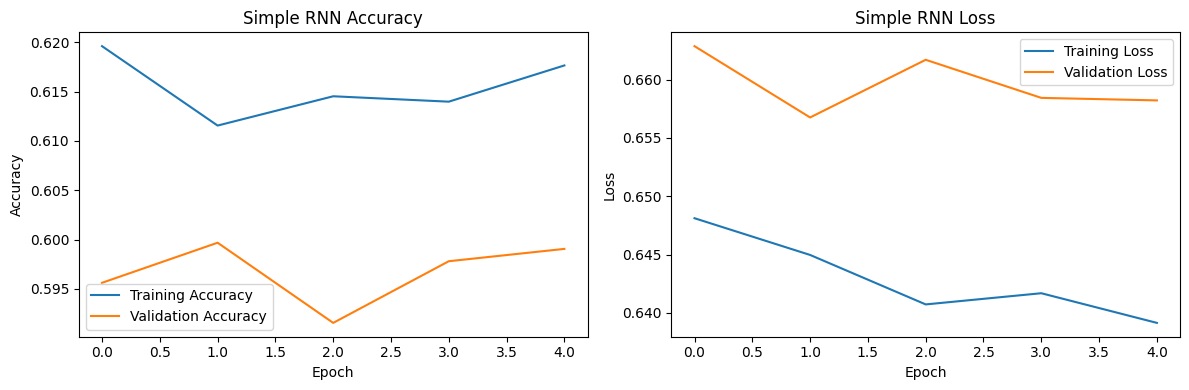

In [21]:
plot_training_history(simple_rnn_history, "Simple RNN")

Model 2: LSTM with Trainable Embedding Layer

In [22]:
lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 492, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,611,521 (9.96 MB)

 Trainable params: 2,611,521 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

The second model uses an LSTM layer instead of a SimpleRNN layer. LSTM is more suitable for longer text because it uses gates to decide what information to remember and forget. This helps the model capture longer word dependencies in news articles.

In [23]:
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

lstm_time = time.time() - start_time
print("LSTM training time:", lstm_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5243 - loss: 0.6873 - val_accuracy: 0.5450 - val_loss: 0.6657 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5425 - loss: 0.6718 - val_accuracy: 0.5516 - val_loss: 0.6678 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5541 - loss: 0.6727 - val_accuracy: 0.5919 - val_loss: 0.6757 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5482 - loss: 0.6618 - val_accuracy: 0.5909 - val_loss: 0.6509 - learning_rate: 5.0000e-04
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.5725 - loss: 0.6863 - val_accuracy: 0.5856 - val_loss: 0.6546 - learning_rate: 5.0000e-04
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.6755 - loss: 0.5777 - val_accuracy: 0.9672 - val_loss: 0.1279 - learning_rate: 5.0000e-04
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.976

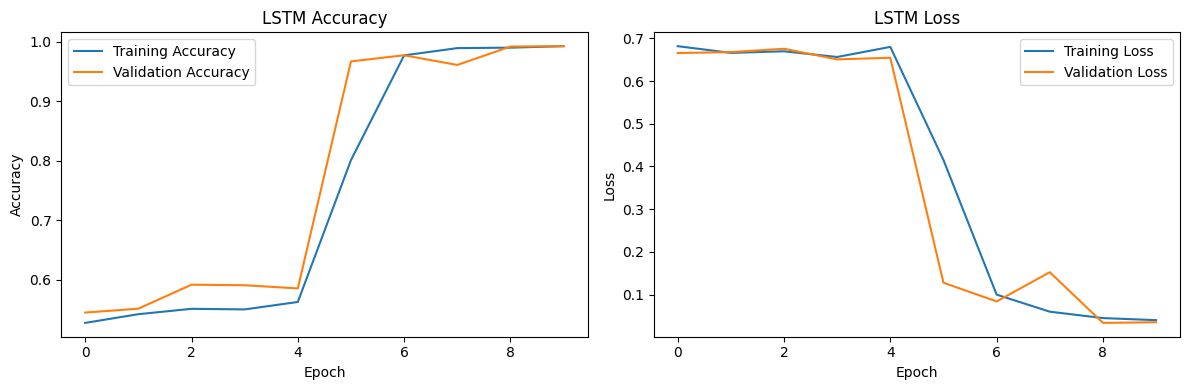

In [24]:
plot_training_history(lstm_history, "LSTM")

Model 3: LSTM with Pretrained Word2Vec Embeddings

In [27]:
import gensim.downloader as api

# Turn on Internet in Kaggle before this cell.
# This is the Word2Vec model expected in the assessment, but it is large and may take time to download.
EMBEDDING_SOURCE = "word2vec-google-news-300"

word2vec_vectors = api.load(EMBEDDING_SOURCE)

print("Loaded pretrained embeddings:", EMBEDDING_SOURCE)
print("Vector size:", word2vec_vectors.vector_size)

Loaded pretrained embeddings: word2vec-google-news-300
Vector size: 300


In [28]:
word_index = tokenizer.word_index

num_words = min(VOCAB_SIZE, len(word_index) + 1)
pretrained_dim = word2vec_vectors.vector_size

embedding_matrix = np.zeros((num_words, pretrained_dim))
matched_words = 0

for word, index in word_index.items():
    if index >= num_words:
        continue
    if word in word2vec_vectors:
        embedding_matrix[index] = word2vec_vectors[word]
        matched_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Matched words:", matched_words)
print("Coverage:", round((matched_words / num_words) * 100, 2), "%")

Embedding matrix shape: (20000, 300)
Matched words: 17520
Coverage: 87.6 %


In [29]:
word2vec_lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LENGTH,)),
    layers.Embedding(
        input_dim=num_words,
        output_dim=pretrained_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    layers.LSTM(64),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

word2vec_lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

word2vec_lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 492, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,095,553 (23.25 MB)

 Trainable params: 95,553 (373.25 KB)

 Non-trainable params: 6,000,000 (22.89 MB)

The third model uses pretrained Word2Vec embeddings. Instead of learning word vectors from scratch, the embedding layer is initialized using vectors learned from a large external corpus. The embedding layer is frozen so the pretrained word meanings are preserved during training. This can help the model perform better when useful word relationships already exist in the pretrained embedding space.

In [30]:
start_time = time.time()

word2vec_lstm_history = word2vec_lstm_model.fit(
    X_train_padded,
    y_train,
    validation_split=0.20,
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

word2vec_lstm_time = time.time() - start_time
print("Word2Vec LSTM training time:", word2vec_lstm_time, "seconds")

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5889 - loss: 0.6504 - val_accuracy: 0.9459 - val_loss: 0.1974 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9469 - loss: 0.1958 - val_accuracy: 0.9584 - val_loss: 0.1664 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9548 - loss: 0.1792 - val_accuracy: 0.9184 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9316 - loss: 0.2186 - val_accuracy: 0.9381 - val_loss: 0.2034 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9412 - loss: 0.1972 - val_accuracy: 0.9500 - val_loss: 0.1759 - learning_rate: 5.0000e-04
Word2Vec LSTM training time: 22.65980577468872 seconds


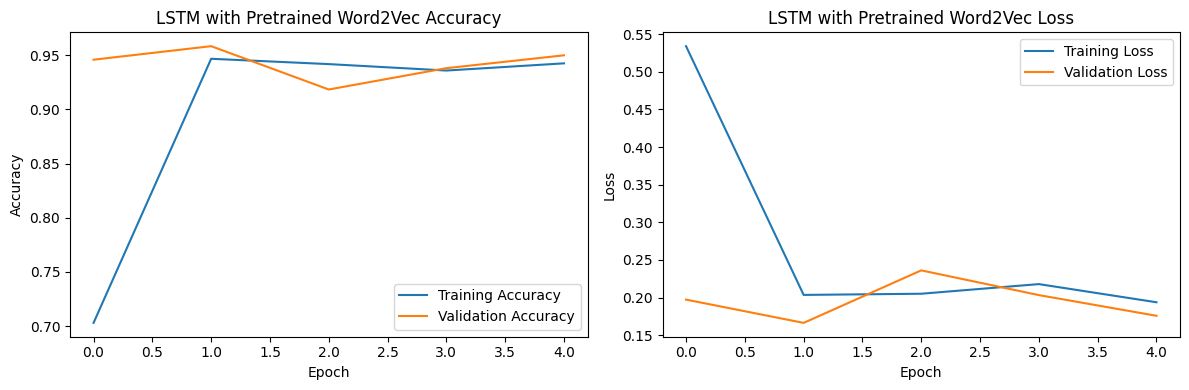

In [31]:
plot_training_history(word2vec_lstm_history, "LSTM with Pretrained Word2Vec")

4.5.3 Model Training and Evaluation

The models are evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report. These metrics help compare the performance of Simple RNN, LSTM, and LSTM with pretrained Word2Vec embeddings.

In [32]:
language_results = []

def evaluate_language_model(model, X_test_data, y_test_data, model_name, training_time):
    probabilities = model.predict(X_test_data, verbose=0).flatten()
    predictions = (probabilities >= 0.5).astype(int)

    print(model_name)
    print(classification_report(
        y_test_data,
        predictions,
        target_names=["Fake", "True"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test_data, predictions)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "True"],
        yticklabels=["Fake", "True"]
    )
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

    accuracy = accuracy_score(y_test_data, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test_data,
        predictions,
        average="weighted",
        zero_division=0
    )

    language_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": training_time
    })

    return predictions, probabilities

Simple RNN
              precision    recall  f1-score   support

        Fake       0.66      0.45      0.53      2000
        True       0.58      0.77      0.66      2000

    accuracy                           0.61      4000
   macro avg       0.62      0.61      0.60      4000
weighted avg       0.62      0.61      0.60      4000



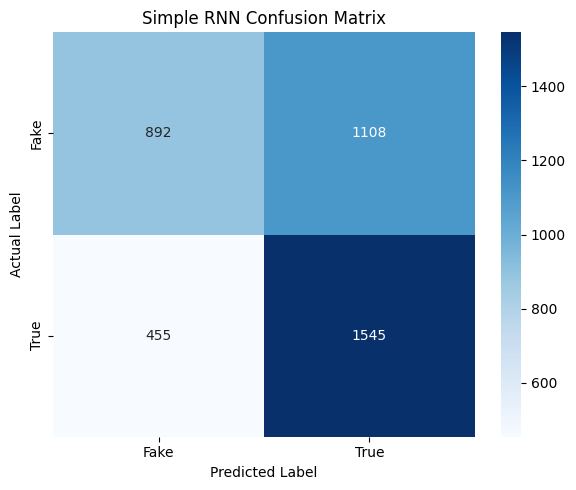

LSTM
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      2000
        True       0.99      1.00      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000



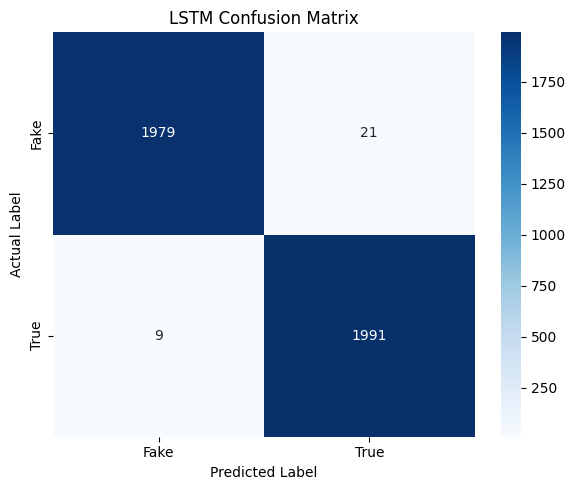

LSTM with Pretrained Word2Vec
              precision    recall  f1-score   support

        Fake       0.98      0.93      0.95      2000
        True       0.93      0.98      0.95      2000

    accuracy                           0.95      4000
   macro avg       0.95      0.95      0.95      4000
weighted avg       0.95      0.95      0.95      4000



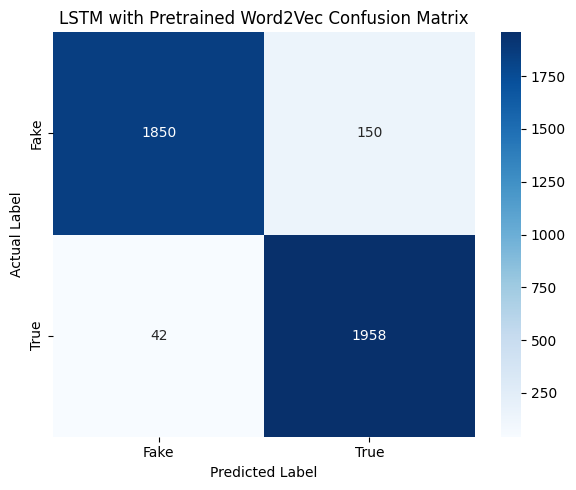

In [33]:
rnn_predictions, rnn_probabilities = evaluate_language_model(
    simple_rnn_model,
    X_test_padded,
    y_test,
    "Simple RNN",
    simple_rnn_time
)

lstm_predictions, lstm_probabilities = evaluate_language_model(
    lstm_model,
    X_test_padded,
    y_test,
    "LSTM",
    lstm_time
)

word2vec_predictions, word2vec_probabilities = evaluate_language_model(
    word2vec_lstm_model,
    X_test_padded,
    y_test,
    "LSTM with Pretrained Word2Vec",
    word2vec_lstm_time
)

Model Performance Comparison

In [34]:
comparison_df = pd.DataFrame(language_results)
comparison_df = comparison_df.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s)
0,LSTM,0.99250,0.992518,0.99250,0.992500,46.253813
1,LSTM with Pretrained Word2Vec,0.95200,0.953322,0.95200,0.951965,22.659806
2,Simple RNN,0.60925,0.622286,0.60925,0.598551,39.467426


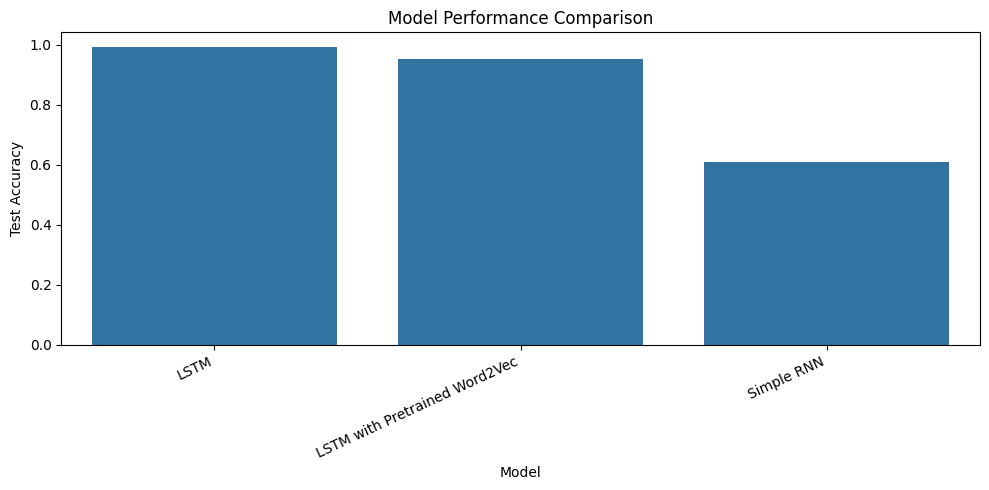

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="Accuracy")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

After training and evaluation, the models are compared using accuracy, precision, recall, F1-score, and training time. Simple RNN is the simplest model, but it may struggle with longer text sequences. LSTM is expected to perform better because it can retain important information over longer sequences. The pretrained Word2Vec LSTM uses external word knowledge, which may improve generalization depending on how well the pretrained vocabulary matches the news dataset.

4.5.4 Error Analysis

In this section, misclassified examples from the best-performing model are analyzed. This helps understand why the model makes mistakes and what improvements may be possible.

In [36]:
best_model_name = comparison_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "Simple RNN":
    best_predictions = rnn_predictions
    best_probabilities = rnn_probabilities
elif best_model_name == "LSTM":
    best_predictions = lstm_predictions
    best_probabilities = lstm_probabilities
else:
    best_predictions = word2vec_predictions
    best_probabilities = word2vec_probabilities

error_analysis_df = pd.DataFrame({
    "original_text": X_test,
    "actual": y_test,
    "predicted": best_predictions,
    "confidence_true": best_probabilities
})

error_analysis_df["actual_label"] = error_analysis_df["actual"].map({0: "Fake", 1: "True"})
error_analysis_df["predicted_label"] = error_analysis_df["predicted"].map({0: "Fake", 1: "True"})

misclassified_df = error_analysis_df[
    error_analysis_df["actual"] != error_analysis_df["predicted"]
]

print("Total misclassified examples:", len(misclassified_df))

display(misclassified_df[[
    "original_text",
    "actual_label",
    "predicted_label",
    "confidence_true"
]].head(3))

Best model: LSTM
Total misclassified examples: 30


,original_text,actual_label,predicted_label,confidence_true
234,carlsbad cavern national park reuters presiden...,True,Fake,0.002533
286,eldest son alaska gov sarah palin beat dayligh...,Fake,True,0.927329
370,jean marie simon passenger flight houston wash...,Fake,True,0.998882


The misclassified examples show that some true and fake news articles can contain similar vocabulary, names, political topics, or emotional language. This can confuse the model because fake news may imitate the style of real news, while real news may include dramatic or controversial wording. Long articles may also contain mixed signals, where some words suggest one class while the full context suggests another.

Model Complexity vs Performance

The Simple RNN is the least complex model, but it may not capture long-term dependencies effectively. The LSTM model is more complex because it uses memory gates, allowing it to retain important information across longer text sequences. The Word2Vec LSTM adds pretrained semantic knowledge, but its performance depends on how many words in the dataset match the pretrained embedding vocabulary. Therefore, higher model complexity can improve performance, but it may also increase training time and computational cost.

Possible Improvements

Possible improvements include using Bidirectional LSTM, GRU, fine-tuning pretrained embeddings, increasing the vocabulary size, tuning sequence length, using stronger regularization, and trying transformer-based models such as BERT. More advanced preprocessing could also help, such as preserving important named entities or handling political phrases more carefully.

4.5.5 GUI for Real-Time Prediction

A simple Gradio interface is created so users can enter news text and receive a real-time prediction from the best model.

In [37]:
if best_model_name == "Simple RNN":
    selected_model = simple_rnn_model
elif best_model_name == "LSTM":
    selected_model = lstm_model
else:
    selected_model = word2vec_lstm_model

def predict_news_text(user_text):
    cleaned = clean_news_text(user_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LENGTH,
        padding="post",
        truncating="post"
    )

    probability_true = selected_model.predict(padded, verbose=0)[0][0]

    if probability_true >= 0.5:
        label = "True News"
        confidence = probability_true
    else:
        label = "Fake News"
        confidence = 1 - probability_true

    return f"Prediction: {label} | Confidence: {confidence:.2%}"

sample_text = "The government announced a new policy after a meeting with officials."
print(predict_news_text(sample_text))

Prediction: Fake News | Confidence: 99.75%


In [38]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])

0

In [39]:
import gradio as gr

demo = gr.Interface(
    fn=predict_news_text,
    inputs=gr.Textbox(lines=6, placeholder="Enter a news article or headline here..."),
    outputs="text",
    title="True vs Fake News Classifier",
    description="Enter news text and the trained model will predict whether it is true or fake."
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1a53285c5bc5353f88.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


The Gradio GUI allows the user to enter a news article or headline and receive a real-time prediction. The input text is cleaned using the same preprocessing function used during training. It is then tokenized, padded, and passed into the best-performing model to predict whether the text is true or fake.

Save Models

In [40]:
simple_rnn_model.save("simple_rnn_model.keras")
lstm_model.save("lstm_model.keras")
word2vec_lstm_model.save("word2vec_lstm_model.keras")

print("All language models saved successfully.")

All language models saved successfully.


Conclusion

This language task implemented a complete text classification pipeline for the True vs Fake News dataset. The dataset was loaded using Pandas and checked for missing values and class distribution. Text preprocessing included lowercasing, contraction handling, URL removal, mention and hashtag removal, number and special character removal, stopword removal, and lemmatization. The cleaned text was tokenized using Keras Tokenizer and padded using a 95th-percentile sequence length.


Three models were trained and compared: Simple RNN with trainable embeddings, LSTM with trainable embeddings, and LSTM with pretrained Word2Vec embeddings. The models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report. The final comparison showed which model performed best based on test metrics and training time.


Error analysis was performed by reviewing misclassified examples, showing that true and fake news can be difficult to separate when they share similar topics, names, or writing styles. A Gradio GUI was also created for real-time prediction, allowing users to enter news text and receive a True/Fake prediction. Overall, the LSTM-based models are more suitable than Simple RNN for this task because they can capture longer text patterns more effectively.